<a href="https://colab.research.google.com/github/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/Q50_Mathematical_Simulation_of_Quantum_Circuits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://qworld.net" target="_blank" align="left"><img src="../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

<font style="font-size:28px;" align="left"><b> Mathematical Simulation of Quantum Circuits </b></font>
<br>
_prepared by Saba Bozpolat_
<br><br>

In [ ]:
!pip install -q qiskit[all] qiskit_aer pylatexenc

We have been designing quantum circuits in Qiskit and reading their statevectors.

In this notebook, we take a step back and ask: what is Qiskit actually computing under the hood?

The answer is matrix-vector multiplication — the same linear algebra we have already been using on the unit circle.

<hr>

<h3>From circuit to matrix expression</h3>

A quantum circuit is a sequence of gate applications on a qubit.

Consider the following simple circuit: we start with $ \ket{0} $, apply the Hadamard gate, and then apply the X gate.

In Qiskit, we write this as:

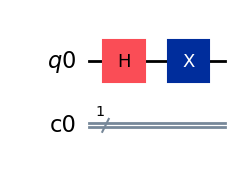

In [3]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)

qc.h(q[0])  # apply H
qc.x(q[0])  # apply X

qc.draw(output='mpl')

Gates are applied left to right in a circuit diagram — H first, then X.

Now, what does this mean mathematically?

Each gate is a matrix. Applying a gate to a state means multiplying the state vector by that matrix:

- Applying H to $ \ket{0} $ gives $ H \ket{0} $.
- Then applying X to the result gives $ X \big( H \ket{0} \big) $.

We can write the full computation as:

$$ \text{final state} = X H \ket{0} $$

<b>Important:</b> The gate applied <i>first</i> in the circuit appears <i>rightmost</i> in the matrix expression. This is because matrix multiplication acts on vectors from the right — exactly like function composition: $ (X \circ H)(v) = X(H(v)) $.

<h3>Computing the result by hand</h3>

Let us carry out the computation step by step.

We know the matrices:

$$ H = \hadamard \qquad X = \X $$

And the initial state:

$$ \ket{0} = \vzero $$

**Step 1:** Apply H to $ \ket{0} $:

$$
H \ket{0} = \hadamard \vzero = \myvector{ \sqrttwo \\ \sqrttwo } = \ket{+}
$$

**Step 2:** Apply X to $ \ket{+} $:

$$
X \ket{+} = \X \myvector{ \sqrttwo \\ \sqrttwo } = \myvector{ \sqrttwo \\ \sqrttwo } = \ket{+}
$$

Interesting — we end up back in $ \ket{+} $. Let us verify this with Qiskit.

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)

qc.h(q[0])
qc.x(q[0])

job = StatevectorSimulator().run(qc, optimization_level=0)
state = job.result().get_statevector(qc).data

print("amplitude of |0>:", round(state[0].real, 4))
print("amplitude of |1>:", round(state[1].real, 4))

The output should match our hand calculation: $ \sqrttwo \approx 0.7071 $ for both amplitudes.

<h3>The combined operator</h3>

Instead of applying gates one by one, we can first multiply the matrices to obtain a single combined operator, and then apply it to the initial state.

For the circuit above:

$$
X H = \X \hadamard = \mymatrix{rr}{ \sqrttwo & -\sqrttwo \\ \sqrttwo & \sqrttwo }
$$

Notice: $XH$ is itself a rotation matrix — specifically $ R(\pi/4) $. The circuit H followed by X is equivalent to a single rotation by $ \pi/4 $.

Applying this to $ \ket{0} $:

$$
(XH) \ket{0} = \mymatrix{rr}{ \sqrttwo & -\sqrttwo \\ \sqrttwo & \sqrttwo } \vzero = \myvector{ \sqrttwo \\ \sqrttwo }
$$

Same result as before, as expected.

<h3> Task 1 </h3>

Consider the circuit that applies X then H (in that order) to $ \ket{0} $.

Write the mathematical expression for the final state.

Compute the final state by hand, step by step.

Then verify your result by running the Qiskit circuit and reading the statevector.

In [ ]:
#
# your solution is here
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task1">click for our solution</a>

<h3>The order of gates matters</h3>

In general, matrix multiplication is not commutative: $ AB \neq BA $.

This means the order of gates in a circuit is significant. Swapping two gates will, in general, produce a different final state.

We already saw one example: $ XH\ket{0} = \ket{+} $, while $ HX\ket{0} = \ket{-} $.

There are, however, special cases where two gates do commute. For example:

$$
ZH \neq HZ \qquad \text{but} \qquad XX = I
$$

We will explore such identities in the tasks below.

<h3> Task 2 </h3>

Start with the state $ \ket{1} $.

Apply the gates in the following order: H, then Z, then H.

Write the mathematical expression $ A \ket{1} $ where $A$ is the combined operator.

Compute the combined operator matrix $A = HZH$ by multiplying the matrices.

What well-known gate does $A$ equal?

Verify using Qiskit.

In [ ]:
#
# your solution is here
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task2">click for our solution</a>

<h3>Reading intermediate states</h3>

Qiskit's StatevectorSimulator accumulates gates as we add them to the circuit. We can read the statevector at any point by running the circuit up to that gate.

This lets us trace the computation step by step and compare each intermediate state to our hand calculation.

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)

# after H
qc1 = QuantumCircuit(q, c)
qc1.h(q[0])
state1 = StatevectorSimulator().run(qc1, optimization_level=0).result().get_statevector(qc1).data
print("After H:  ", [round(a.real, 4) for a in state1])

# after H, X
qc2 = QuantumCircuit(q, c)
qc2.h(q[0])
qc2.x(q[0])
state2 = StatevectorSimulator().run(qc2, optimization_level=0).result().get_statevector(qc2).data
print("After H,X:", [round(a.real, 4) for a in state2])

# after H, X, Z
qc3 = QuantumCircuit(q, c)
qc3.h(q[0])
qc3.x(q[0])
qc3.z(q[0])
state3 = StatevectorSimulator().run(qc3, optimization_level=0).result().get_statevector(qc3).data
print("After H,X,Z:", [round(a.real, 4) for a in state3])

<h3> Task 3 </h3>

The circuit above ends with the state after H, X, Z applied to $ \ket{0} $.

Before running the code, predict the final state by computing $ Z X H \ket{0} $ by hand.

Does the Qiskit output match your prediction?

In [ ]:
#
# no code required — write your hand calculation here as comments
# then check against the output of the cell above
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task3">click for our solution</a>

<hr>
<h3>Unitary matrices and reversibility</h3>

Every quantum gate matrix $U$ satisfies the property:

$$ U^T U = I $$

where $U^T$ is the transpose of $U$ (we are working with real-valued gates throughout this tutorial, so the transpose suffices here).

Such a matrix is called <b>orthogonal</b> (or more generally, <b>unitary</b>). It preserves the length of any state vector:

$$ \norm{ U \ket{v} } = \norm{ \ket{v} } $$

This is not a coincidence — it is a requirement. A quantum state must always remain a unit vector (the sum of squared amplitudes must equal 1), so every valid quantum gate must be unitary.

A useful consequence: since $ U^T U = I $, we have $ U^{-1} = U^T $. Every gate is invertible, and its inverse is simply its transpose. Quantum computation is inherently reversible.

For example:

$$ H^{-1} = H^T = H \qquad X^{-1} = X^T = X \qquad Z^{-1} = Z^T = Z $$

All three gates are their own inverses.

<h3> Task 4 </h3>

Verify by hand that $ H^T H = I $.

Then design a Qiskit circuit that applies H twice to $ \ket{1} $ and confirm that the final state is $ \ket{1} $.

In [ ]:
#
# your solution is here
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task4">click for our solution</a>

<hr>
<h3>Inverting a circuit</h3>

Since every gate is its own inverse (for H, X, Z), we can undo a sequence of gates by applying them in reverse order.

If the circuit applies gates $ A $, then $ B $, then $ C $ to some initial state, the combined operator is $ C B A $.

To invert this, we need:

$$ (CBA)^{-1} = A^{-1} B^{-1} C^{-1} $$

For H, X, Z where each gate equals its own inverse:

$$ (CBA)^{-1} = A B C $$

So to undo the circuit, apply the same gates in reverse order.

<h3> Task 5 </h3>

Design a circuit that applies the following sequence of gates to $ \ket{0} $:

$$ H \to X \to Z \to H $$

Then, extend the circuit by appending the inverse of this sequence.

The final state of the combined circuit should be $ \ket{0} $.

Verify with Qiskit.

In [ ]:
#
# your solution is here
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task5">click for our solution</a>

<hr>
<h3>Gates and rotations</h3>

We have already seen that every quantum gate on a single real-valued qubit acts as either a rotation or a reflection on the unit circle.

- $ H $, $ X $, $ Z $ are reflections.
- $ R_y(\theta) $ is a rotation.

A product of two reflections is a rotation. This means a circuit like $ XH $ or $ HZ $ is equivalent to some rotation.

A product of two rotations is also a rotation. A product of a reflection and a rotation is a reflection.

This geometric perspective can help us predict the type of combined operator before doing any matrix multiplication.

<h3> Task 6 (Extra) </h3>

Consider the following circuit: apply $ R_y(\pi/3) $, then $ H $, then $ R_y(\pi/6) $ to $ \ket{0} $.

<b>(a)</b> Write the mathematical expression for the final state.

<b>(b)</b> Without computing the matrix product, determine whether the combined operator $ R_y(\pi/6) \, H \, R_y(\pi/3) $ is a rotation or a reflection. Explain your reasoning.

<b>(c)</b> Compute the final state by applying the gates one by one.

<b>(d)</b> Verify with Qiskit by reading the final statevector and drawing the state on the unit circle.

In [ ]:
%run quantum.py

#
# your solution is here
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task6">click for our solution</a>